In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def create_draws(mean, lower, upper):
    '''For the purpose of severity splits or duration'''
    seed = 100
    np.random.seed(seed)
    sd = (upper - lower) / (2 * 1.96)
    sample_size = mean * (1 - mean) / sd ** 2
    alpha = mean * sample_size
    beta = (1 - mean) * sample_size
    draws = np.random.beta(alpha, beta, size=1000)
    #Using the beta distribution
    # The Beta distribution is parameterized by two shape parameters, alpha and beta, which are derived from the mean and standard deviation.
    return draws

def create_log_normal_draws(mean, lower, upper):
    '''Generates draws from a log-normal distribution for the purpose of severity splits or duration'''
    seed = 100
    np.random.seed(seed)
    # Transform mean, lower, and upper bounds to the log scale
    log_lower = np.log(lower)
    log_upper = np.log(upper)
    log_mean = np.log(mean)
    # Assuming lower and upper bounds represent a 95% confidence interval, 
    # which spans 1.96 standard deviations from the mean in both directions
    # in the log scale
    log_sd = (log_upper - log_lower) / (2 * 1.96)
    # Generate draws from a log-normal distribution
    log_draws = np.random.normal(log_mean, log_sd, size=1000)
    #A log-normal distribution is a probability distribution of a random variable whose logarithm is normally distributed. This distribution is useful when modeling data that is positively skewed, meaning it cannot be negative and is multiplicative.
    # Transform back to the original scale
    draws = np.exp(log_draws)
    return draws


def create_exponential_draws(mean, lower, upper):
    '''Generates draws from an exponential distribution for the purpose of severity splits or duration'''
    seed = 100
    np.random.seed(seed)
    # The rate parameter for the exponential distribution is the inverse of the mean
    rate = 1 / mean
    # Generate draws from an exponential distribution
    draws = np.random.exponential(scale=1/rate, size=1000)
    # The Exponential distribution is used to model the time between events in a Poisson process, where events occur continuously and independently at a constant average rate.
    return draws

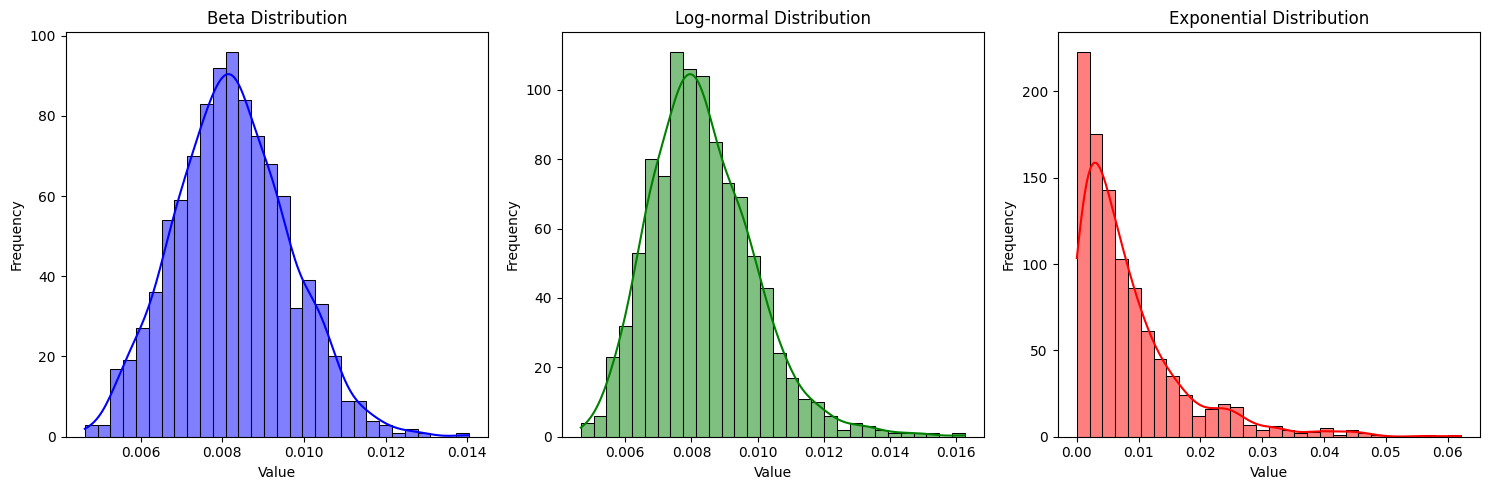

In [31]:
# Parameters
mean = 3 / 365
lower = 2/ 365
upper = 4/ 365

#uncomplicated_subacute_dur = self.create_log_normal_draws(12.14 / 365, 11.7 / 365, 12.58 / 365)
#complicated_acute_dur = self.create_log_normal_draws(3 / 365,  2/ 365,  4/ 365)

# Generate draws
beta_draws = create_draws(mean, lower, upper)
log_normal_draws = create_log_normal_draws(mean, lower, upper)
exponential_draws = create_exponential_draws(mean, lower, upper)

# Plotting
plt.figure(figsize=(15, 5))

# Beta distribution
plt.subplot(1, 3, 1)
sns.histplot(beta_draws, kde=True, bins=30, color='blue')
plt.title('Beta Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Log-normal distribution
plt.subplot(1, 3, 2)
sns.histplot(log_normal_draws, kde=True, bins=30, color='green')
plt.title('Log-normal Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Exponential distribution
plt.subplot(1, 3, 3)
sns.histplot(exponential_draws, kde=True, bins=30, color='red')
plt.title('Exponential Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [10]:
print(exponential_draws)

[6.82043780e-01 2.83830440e-01 4.80715557e-01 1.62071160e+00
 4.11512187e-03 1.12767708e-01 9.66513588e-01 1.52063307e+00
 1.27890572e-01 7.44620588e-01 1.93084796e+00 2.04200198e-01
 1.78323874e-01 9.97992300e-02 2.15824036e-01 3.34556448e+00
 1.45257754e+00 1.64143671e-01 1.47381630e+00 2.78666959e-01
 4.91648477e-01 2.44809982e+00 1.48058684e+00 3.56388317e-01
 1.67796496e-01 4.05890588e-01 4.96313122e-03 2.53102536e-01
 1.38154459e+00 1.33740971e-02 7.94660912e-01 8.05487413e-01
 9.66540298e-02 4.18622522e-01 3.23274087e-02 1.92359037e+00
 3.44446879e+00 5.37779117e-02 1.92465785e+00 7.48330731e-01
 1.18029132e+00 8.65432085e-01 7.58549857e-01 1.79662844e-02
 2.05107700e-01 6.84486006e-01 1.27527755e+00 2.51090243e-01
 2.92951825e-01 1.66449800e+00 3.20955113e+00 1.88054698e+00
 3.87601012e-01 7.94694677e-01 3.81223674e-01 3.61749211e-01
 1.70618672e-01 2.36124527e-01 3.99327756e-02 6.12540440e-01
 4.10648323e-01 7.81663747e-01 8.64862818e-01 1.33850450e-01
 2.36265802e+00 2.545472

/tmp/ipykernel_1155973/1675076844.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Distribution', y='Value', data=df_melted, jitter=True, palette='Set1')


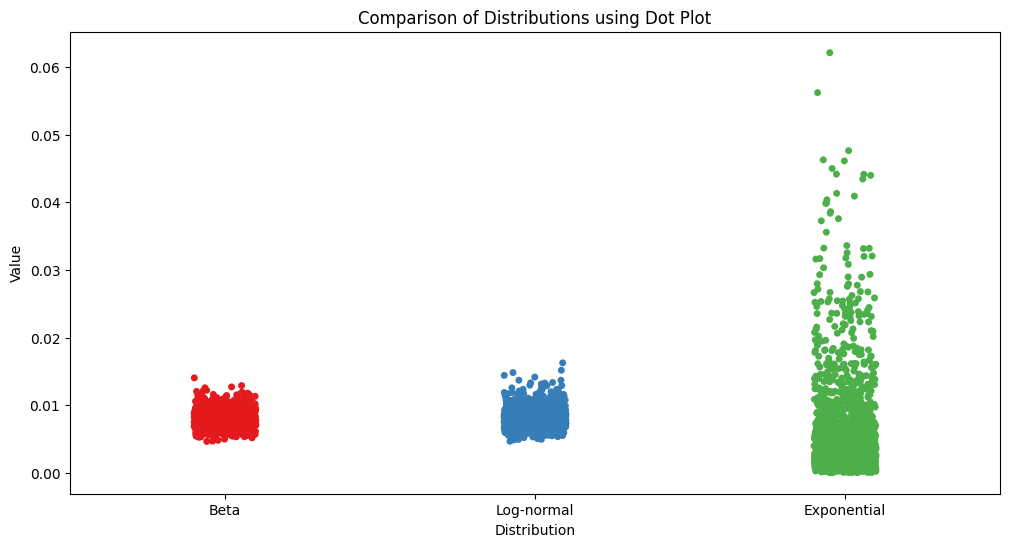

In [32]:
# Combine data for plotting
data = {
    'Beta': beta_draws,
    'Log-normal': log_normal_draws,
    'Exponential': exponential_draws
}

# Convert to long format
import pandas as pd
df = pd.DataFrame(data)
df_melted = df.melt(var_name='Distribution', value_name='Value')

# Plotting
plt.figure(figsize=(12, 6))
sns.stripplot(x='Distribution', y='Value', data=df_melted, jitter=True, palette='Set1')
plt.title('Comparison of Distributions using Dot Plot')
plt.xlabel('Distribution')
plt.ylabel('Value')
plt.show()

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages

# Convert to long format
df = pd.DataFrame(data)
df_melted = df.melt(var_name='Distribution', value_name='Value')

# Create PDF
with PdfPages('complicated_acute_dur_distributions.pdf') as pdf:
    # Plot histograms
    plt.figure(figsize=(15, 5))

    # Beta distribution
    plt.subplot(1, 3, 1)
    sns.histplot(beta_draws, kde=True, bins=30, color='blue')
    plt.title('Beta Distribution')
    plt.xlabel('Value')
    plt.ylabel('Frequency')

    # Log-normal distribution
    plt.subplot(1, 3, 2)
    sns.histplot(log_normal_draws, kde=True, bins=30, color='green')
    plt.title('Log-normal Distribution')
    plt.xlabel('Value')
    plt.ylabel('Frequency')

    # Exponential distribution
    plt.subplot(1, 3, 3)
    sns.histplot(exponential_draws, kde=True, bins=30, color='red')
    plt.title('Exponential Distribution')
    plt.xlabel('Value')
    plt.ylabel('Frequency')

    plt.tight_layout()
    pdf.savefig()  # Save the current figure into the PDF
    plt.close()

    # Plot dot plots
    plt.figure(figsize=(12, 6))
    sns.stripplot(x='Distribution', y='Value', data=df_melted, jitter=True, palette='Set1')
    plt.title('Comparison of Distributions using Dot Plot')
    plt.xlabel('Distribution')
    plt.ylabel('Value')
    pdf.savefig()  # Save the current figure into the PDF
    plt.close()

/tmp/ipykernel_1155973/2516493205.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='Distribution', y='Value', data=df_melted, jitter=True, palette='Set1')
